# Proyek Analisis Data: Bike Sharing Dataset
- **Nama: Hikmal Arya Dwitama**
- **Email: cdcc200d6y1003@student.devacademy.id**
- **ID Dicoding: CDCC200D6Y1003**

# Menentukan Pertanyaan Bisnis
1. Bagaimana pengaruh suhu (temp) dan kelembaban (hum) terhadap jumlah penyewaan sepeda selama periode 2011–2012?
2. Bagaimana tren jumlah penyewaan sepeda (cnt) dari waktu ke waktu selama periode 2011–2012, dan kapan terjadi puncak serta penurunannya?
3. Apakah terdapat perbedaan jumlah penyewaan sepeda (cnt) antara hari kerja dan hari libur serta antar musim selama periode 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [49]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set(style="whitegrid")

# Data Wrangling

### Gathering Data

In [63]:
# Load dataset
df = pd.read_csv("data/day.csv")

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** Dataset berisi data penyewaan sepeda harian dengan variabel waktu, cuaca, dan jumlah penyewaan (cnt). Beberapa variabel kategori masih berupa angka sehingga perlu mapping pada tahap cleaning.

### Assessing dataset

In [64]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [65]:
# Statistik deskriptif
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [66]:
# Cek Missing value
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [67]:
# Cek Data Duplikat
df.duplicated().sum()

np.int64(0)

In [68]:
# Cek nilai unik pada variabel kategorik
df["season"].value_counts()

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64

In [69]:
df["workingday"].value_counts()

workingday
1    500
0    231
Name: count, dtype: int64

**Insight:** Dataset terdiri dari 731 data tanpa missing value dan duplikasi, sehingga kualitas data sudah baik. Variabel dteday masih bertipe object dan perlu dikonversi ke datetime. Nilai cnt memiliki rentang yang cukup besar, menunjukkan adanya variasi penyewaan antar hari.

### Data Cleaning

In [70]:
# Konversi tipe data tanggal
df["dteday"] = pd.to_datetime(df["dteday"])

In [71]:
# Mapping season
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

# pastikan tipe integer dulu
df["season"] = df["season"].astype(int)

df["season"] = df["season"].map(season_map)

In [72]:
# Mapping workingday
df["workingday"] = df["workingday"].map({
    0: "Holiday",
    1: "Working Day"
})

In [76]:
# Cek ulang missing value setelah cleaning
print("Missing values:\n", df.isna().sum())

Missing values:
 instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [ ]:
# Cek ulang data duplikasi setelah cleaning
print("\nJumlah duplikasi:", df.duplicated().sum())


Jumlah duplikasi: 0


In [77]:
# Statistik Deskriptif Data Setelah Cleaning
df.describe()

,instant,dteday,yr,mnth,holiday,weekday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,6.519836,0.028728,2.997264,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,4.000000,0.000000,1.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,7.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,10.000000,0.000000,5.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,12.000000,1.000000,6.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,3.451913,0.167155,2.004787,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [78]:
# Simpan dataset hasil cleaning
df.to_csv("dashboard/main_data.csv", index=False)
print("Dataset berhasil disimpan ke dashboard/main_data.csv")

Dataset berhasil disimpan ke dashboard/main_data.csv


**Insight:** Tipe data dteday berhasil dikonversi menjadi datetime, dan variabel season serta workingday telah diubah menjadi kategori yang lebih mudah dipahami. Setelah proses cleaning, tidak ditemukan missing values maupun duplikasi, sehingga data sudah bersih dan siap untuk dianalisis lebih lanjut.

# Exploratory Data Analysis (EDA)

### Data Overview

In [81]:
# Menampilkan sampel data
df.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
332,333,2011-11-29,Winter,0,11,0,2,Working Day,2,0.458333,0.451375,0.830833,0.258092,96,2818,2914
15,16,2011-01-16,Spring,0,1,0,0,Holiday,1,0.231667,0.234217,0.483750,0.188433,251,953,1204
65,66,2011-03-07,Spring,0,3,0,1,Working Day,1,0.261739,0.238461,0.551304,0.341352,244,1628,1872
220,221,2011-08-09,Fall,0,8,0,2,Working Day,1,0.775000,0.724121,0.570417,0.151121,907,3695,4602
690,691,2012-11-21,Winter,1,11,0,3,Working Day,1,0.353333,0.364892,0.613750,0.103246,615,4531,5146


In [ ]:
# Menampilkan informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    object        
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [83]:
# Rentang Waktu yang Digunakan
print("Tanggal awal:", df["dteday"].min())
print("Tanggal akhir:", df["dteday"].max())

Tanggal awal: 2011-01-01 00:00:00
Tanggal akhir: 2012-12-31 00:00:00


### Univariate Analysis

Analisis univariat dilakukan untuk memahami distribusi masing-masing variabel secara individual, khususnya variabel numerik yang digunakan dalam analisis.

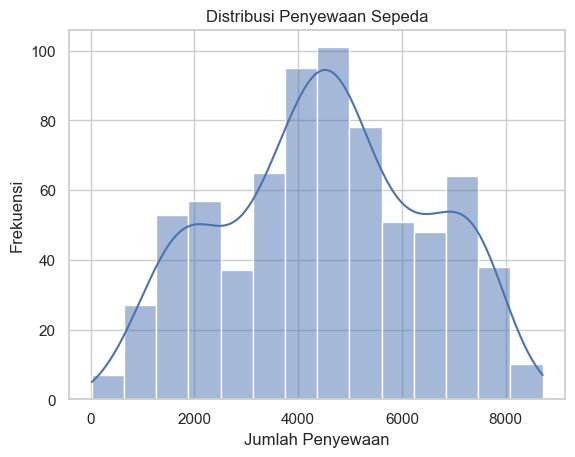

In [84]:
# Histogram Penyewaan Sepeda
sns.histplot(df["cnt"], kde=True)
plt.title("Distribusi Penyewaan Sepeda")
plt.xlabel("Jumlah Penyewaan")
plt.ylabel("Frekuensi")
plt.show()

**Insight:** Distribusi jumlah penyewaan sepeda cenderung mendekati normal dengan sebagian besar nilai berada pada tingkat menengah. Hal ini menunjukkan bahwa pola penggunaan sepeda relatif stabil tanpa fluktuasi ekstrem yang signifikan.

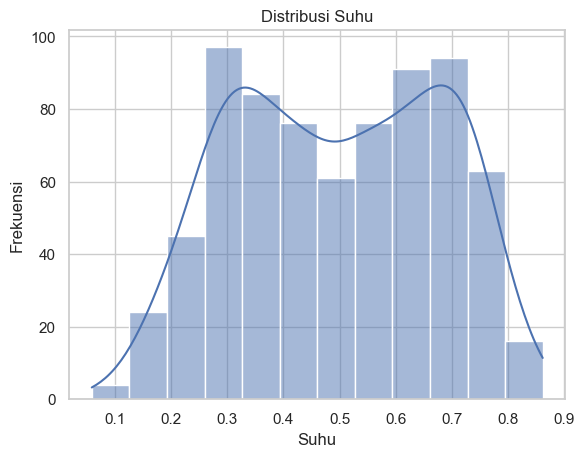

In [85]:
# Histogram Suhu (temp)
sns.histplot(df["temp"], kde=True)
plt.title("Distribusi Suhu")
plt.xlabel("Suhu")
plt.ylabel("Frekuensi")
plt.show()

**Insight:** Distribusi suhu menunjukkan sebaran yang cukup merata dengan konsentrasi pada nilai menengah. Hal ini menunjukkan bahwa sebagian besar kondisi cuaca berada pada tingkat suhu yang relatif nyaman.

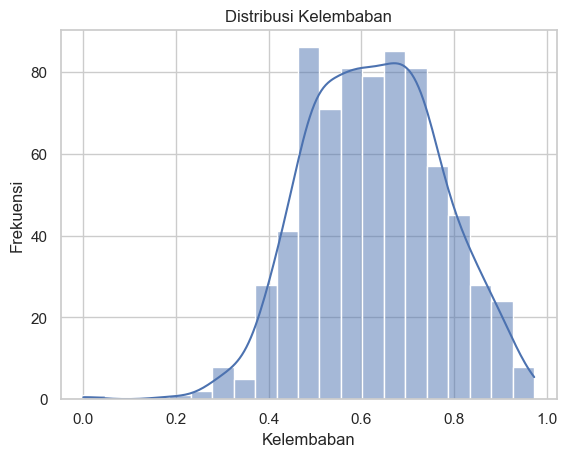

In [89]:
# Histogram Kelembaban (hum)
sns.histplot(df["hum"], kde=True)
plt.title("Distribusi Kelembaban")
plt.xlabel("Kelembaban")
plt.ylabel("Frekuensi")
plt.show()

**Insight:** Distribusi kelembaban cenderung terkonsentrasi pada nilai menengah hingga tinggi dengan variasi yang cukup luas, yang dapat memengaruhi tingkat kenyamanan pengguna dalam menggunakan sepeda.

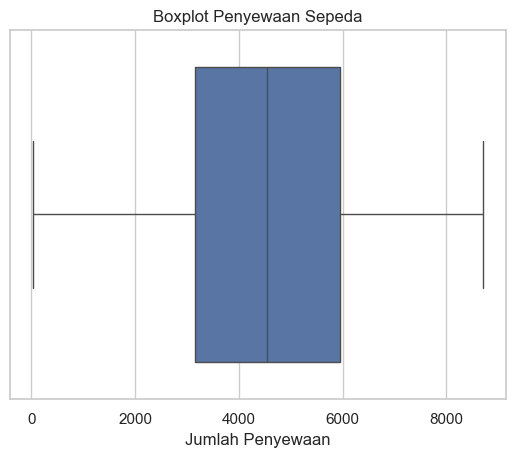

In [ ]:
# Boxplot Penyewaan Sepeda
sns.boxplot(x=df["cnt"])
plt.title("Boxplot Penyewaan Sepeda")
plt.xlabel("Jumlah Penyewaan")
plt.show()

**Insight:** Boxplot menunjukkan bahwa sebagian besar data penyewaan berada pada rentang menengah dengan median yang cukup stabil. Tidak terdapat outlier ekstrem yang signifikan, sehingga distribusi data relatif konsisten.

In [88]:
# Skewness & Kurtosis
df[["cnt","temp","hum"]].skew()
df[["cnt","temp","hum"]].kurt()

cnt    -0.811922
temp   -1.118864
hum    -0.064530
dtype: float64

**Insight:** Nilai skewness menunjukkan bahwa variabel cnt dan temp cenderung memiliki distribusi miring ke kiri (negatif), sedangkan hum relatif simetris. Hal ini menunjukkan bahwa sebagian besar nilai berada pada rentang yang lebih tinggi, namun distribusi data secara keseluruhan masih dalam batas wajar untuk dianalisis lebih lanjut.

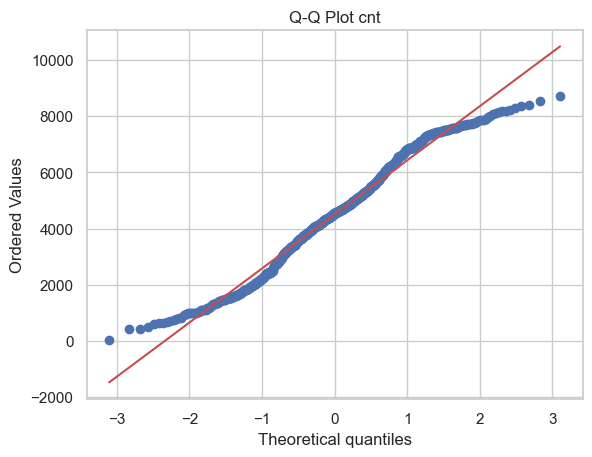

In [ ]:
# Q-Q Plot (cnt)
stats.probplot(df["cnt"], dist="norm", plot=plt)
plt.title("Q-Q Plot cnt")
plt.show()

**Insight:** Titik-titik pada Q-Q plot sebagian besar mengikuti garis diagonal, yang menunjukkan bahwa distribusi cnt mendekati normal. Namun, terdapat sedikit penyimpangan pada bagian ekor yang mengindikasikan adanya nilai ekstrem, meskipun tidak signifikan.

### Multivariate Analysis

Analisis multivariat dilakukan untuk memahami hubungan antar variabel, khususnya pengaruh suhu (temp) dan kelembaban (hum) terhadap jumlah penyewaan sepeda (cnt).

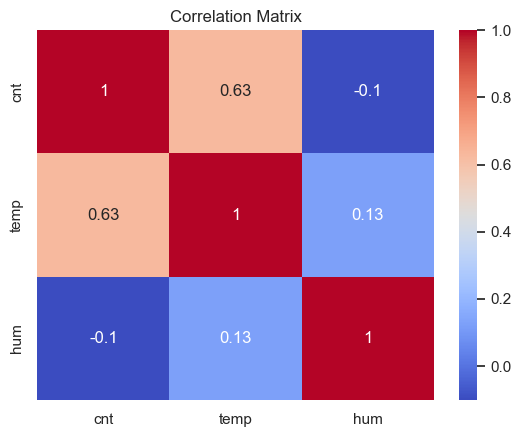

In [23]:
# Correlation Matrix (cnt, temp, hum)
cols = ["cnt","temp","hum"]

sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Insight:** Suhu (temp) memiliki korelasi positif yang cukup kuat dengan jumlah penyewaan sepeda (cnt), yang menunjukkan bahwa semakin tinggi suhu, semakin meningkat jumlah penyewaan. Sebaliknya, kelembaban (hum) memiliki korelasi negatif yang lemah terhadap penyewaan, sehingga pengaruhnya tidak terlalu signifikan.

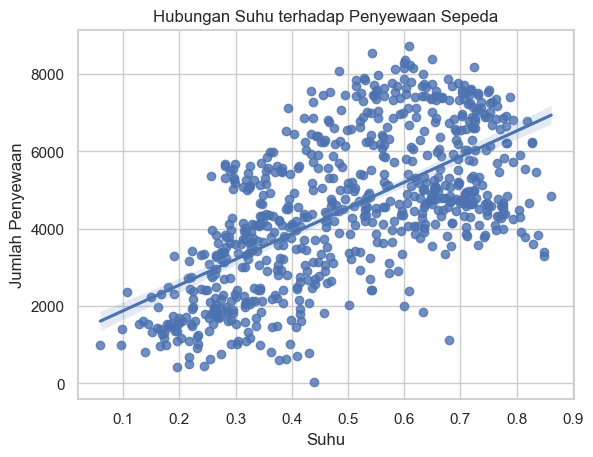

In [90]:
# Hubungan Suhu dan Penyewaan sepeda (temp vs cnt)
sns.regplot(x="temp", y="cnt", data=df)
plt.title("Hubungan Suhu terhadap Penyewaan Sepeda")
plt.xlabel("Suhu")
plt.ylabel("Jumlah Penyewaan")
plt.show()

**Insight:** Scatter plot menunjukkan hubungan positif antara suhu dan jumlah penyewaan. Semakin tinggi suhu, semakin meningkat jumlah penyewaan sepeda, meskipun terdapat variasi data pada setiap tingkat suhu.

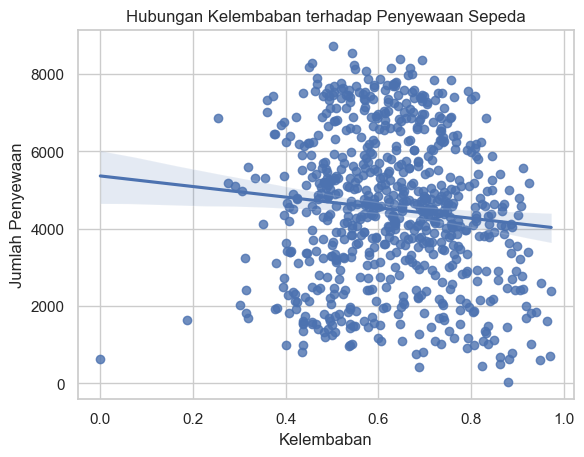

In [91]:
# Hubungan Kelembaban dan Penyewaan (hum vs cnt)
sns.regplot(x="hum", y="cnt", data=df)
plt.title("Hubungan Kelembaban terhadap Penyewaan Sepeda")
plt.xlabel("Kelembaban")
plt.ylabel("Jumlah Penyewaan")
plt.show()

**Insight:** Scatter plot menunjukkan hubungan negatif yang lemah antara kelembaban dan jumlah penyewaan. Peningkatan kelembaban cenderung diikuti penurunan jumlah penyewaan, namun hubungan ini tidak terlalu kuat karena penyebaran data cukup luas.

In [92]:
# Korelasi angka
df[["cnt","temp","hum"]].corr()

,cnt,temp,hum
cnt,1.000000,0.627494,-0.100659
temp,0.627494,1.000000,0.126963
hum,-0.100659,0.126963,1.000000


**Insight:** Hasil korelasi menunjukkan bahwa suhu (temp) memiliki hubungan positif yang cukup kuat dengan jumlah penyewaan sepeda (cnt) dengan nilai sekitar 0.62. Sementara itu, kelembaban (hum) memiliki korelasi negatif yang sangat lemah terhadap penyewaan, sehingga pengaruhnya relatif kecil dibandingkan suhu.

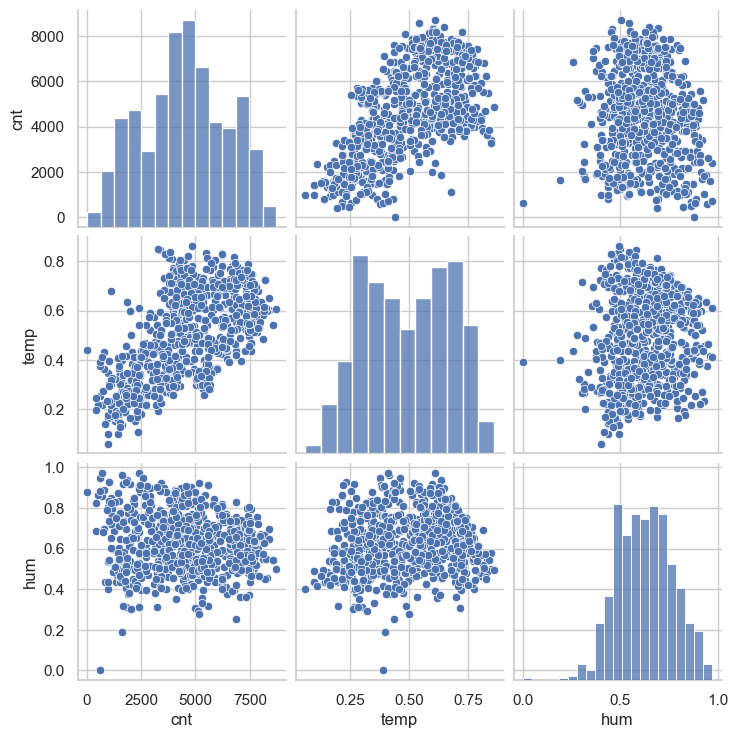

In [93]:
# Pairplot
sns.pairplot(df[["cnt","temp","hum"]])

**Insight:** Pairplot menunjukkan adanya hubungan positif antara suhu (temp) dan jumlah penyewaan sepeda (cnt), di mana titik-titik cenderung membentuk pola meningkat. Sebaliknya, hubungan antara kelembaban (hum) dan jumlah penyewaan terlihat lebih menyebar tanpa pola yang jelas, yang mengindikasikan hubungan yang lemah. Selain itu, distribusi pada diagonal menunjukkan bahwa sebagian besar data berada pada rentang nilai menengah untuk masing-masing variabel.

### Numerical Analysis

Analisis numerik dilakukan untuk memahami karakteristik statistik data, termasuk distribusi, variasi, dan perbedaan antar kelompok.

In [26]:
# Analisis Percentile (cnt)
df["cnt"].describe(percentiles=[0.05, 0.1, 0.9, 0.95])

count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
5%       1331.000000
10%      1746.000000
50%      4548.000000
90%      7290.000000
95%      7576.000000
max      8714.000000
Name: cnt, dtype: float64

**Insight:** Nilai mean (4504) dan median (4548) yang berdekatan menunjukkan distribusi data yang relatif simetris. Rentang antara persentil 10% (1746) dan 90% (7290) menunjukkan variasi penyewaan yang cukup besar, mengindikasikan adanya perbedaan signifikan antara hari dengan penyewaan rendah dan tinggi.

In [99]:
# Uji Normalitas (Shapiro-Wilk)
from scipy.stats import shapiro

stat, p = shapiro(df["cnt"])
print("Statistic:", stat)
print("p-value:", p)

Statistic: 0.9801244259421663
p-value: 2.0812940617668e-08


**Insight:** Hasil uji Shapiro-Wilk menunjukkan bahwa nilai p-value sangat kecil (p < 0.05), sehingga distribusi data cnt tidak sepenuhnya normal. Hal ini mengindikasikan adanya sedikit penyimpangan pada distribusi, meskipun secara visual sebelumnya terlihat mendekati normal.

In [100]:
# Analisis Variansi berdasarkan Musim
df.groupby("season")["cnt"].agg(["mean", "std", "var"])

,mean,std,var
season,,,
Fall,5644.303191,1459.800381,2.131017e+06
Spring,2604.132597,1399.942119,1.959838e+06
Summer,4992.331522,1695.977235,2.876339e+06
Winter,4728.162921,1699.615261,2.888692e+06


**Insight:** Jumlah penyewaan sepeda berbeda antar musim, dengan nilai rata-rata tertinggi terjadi pada musim Fall dan terendah pada musim Spring. Selain itu, nilai standar deviasi yang cukup besar pada beberapa musim menunjukkan adanya variasi penyewaan yang tinggi, sehingga faktor musiman berpengaruh terhadap tingkat dan fluktuasi penyewaan sepeda.

In [101]:
# Analisis Variansi berdasarkan Kondisi Cuaca
df.groupby("weathersit")["cnt"].agg(["mean", "std", "var"])

,mean,std,var
weathersit,,,
1,4876.786177,1879.483989,3.532460e+06
2,4035.862348,1809.109918,3.272879e+06
3,1803.285714,1240.284449,1.538306e+06


**Insight:** Kondisi cuaca memiliki pengaruh terhadap jumlah penyewaan sepeda, di mana kondisi cuaca yang lebih baik memiliki rata-rata penyewaan yang lebih tinggi. Sebaliknya, kondisi cuaca yang buruk menunjukkan penurunan signifikan dalam jumlah penyewaan, yang menunjukkan bahwa cuaca menjadi faktor penting dalam menentukan aktivitas penyewaan sepeda.

### Categorical Analysis

Analisis kategorikal dilakukan untuk melihat perbedaan jumlah penyewaan sepeda (cnt) berdasarkan variabel kategori, yaitu workingday dan season.

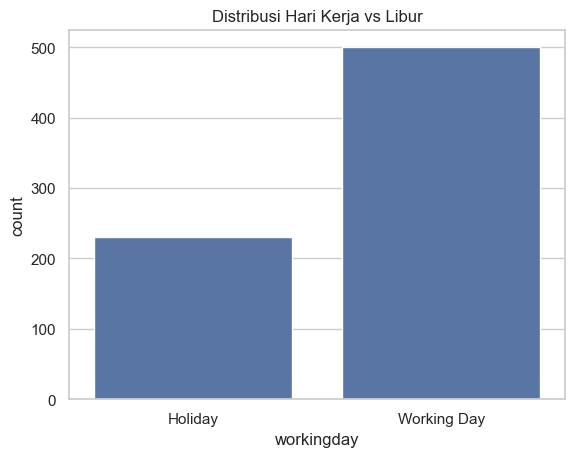

In [102]:
# Distribusi kategori workingday
sns.countplot(x="workingday", data=df)
plt.title("Distribusi Hari Kerja vs Libur")
plt.show()

**Insight:** Distribusi data menunjukkan bahwa jumlah observasi pada hari kerja (working day) lebih banyak dibandingkan hari libur (holiday), namun perbedaan jumlah penyewaan tidak terlalu signifikan secara distribusi.

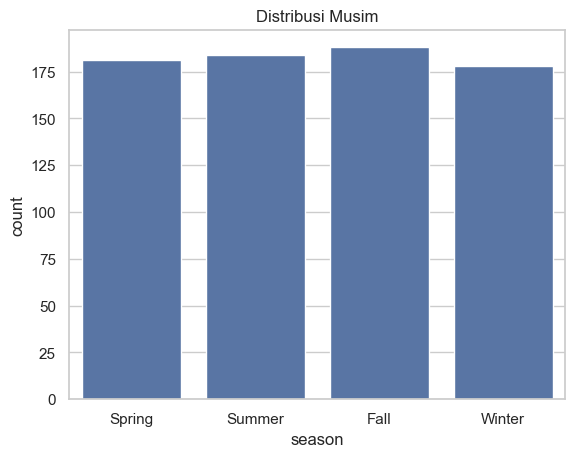

In [103]:
# Distribusi kategori season
sns.countplot(x="season", data=df)
plt.title("Distribusi Musim")
plt.show()

**Insight:** Distribusi jumlah data pada setiap musim relatif seimbang, sehingga tidak ada bias data yang signifikan antar musim. Hal ini menunjukkan bahwa analisis perbandingan antar musim dapat dilakukan dengan cukup fair.

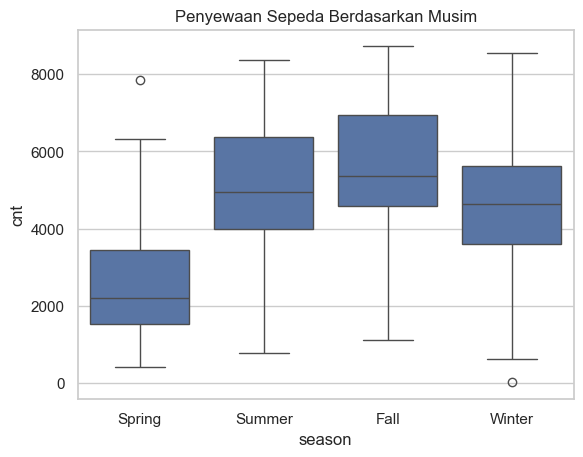

In [104]:
# Penyewaan berdasarkan musim
sns.boxplot(x="season", y="cnt", data=df)
plt.title("Penyewaan Sepeda Berdasarkan Musim")
plt.show()

**Insight:** Terlihat perbedaan distribusi jumlah penyewaan sepeda (cnt) antar musim. Musim Fall dan Summer memiliki median penyewaan yang lebih tinggi dibandingkan Spring dan Winter. Selain itu, variasi data pada Fall dan Summer juga lebih besar, menunjukkan bahwa pada musim tersebut permintaan sepeda cenderung lebih tinggi dan lebih bervariasi.

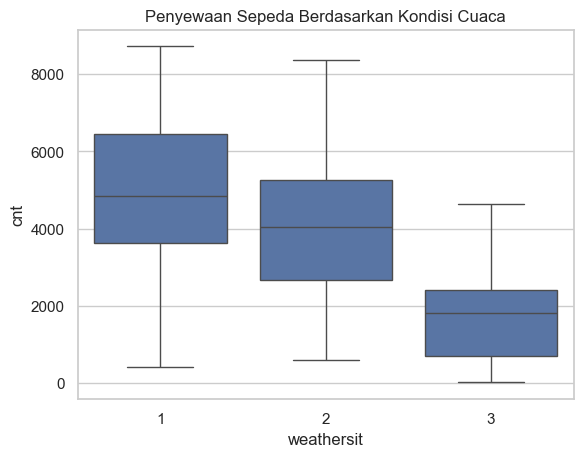

In [105]:
# Penyewaan berdasarkan kondisi cuaca
sns.boxplot(x="weathersit", y="cnt", data=df)
plt.title("Penyewaan Sepeda Berdasarkan Kondisi Cuaca")
plt.show()

**Insight:** Distribusi penyewaan sepeda menunjukkan bahwa kondisi cuaca sangat berpengaruh terhadap jumlah penyewaan. Pada kondisi cuaca baik (weathersit = 1), median penyewaan paling tinggi. Saat kondisi memburuk (weathersit = 2 dan 3), jumlah penyewaan menurun secara signifikan. Hal ini menunjukkan bahwa pengguna cenderung lebih banyak menyewa sepeda saat cuaca cerah dibandingkan saat cuaca buruk.

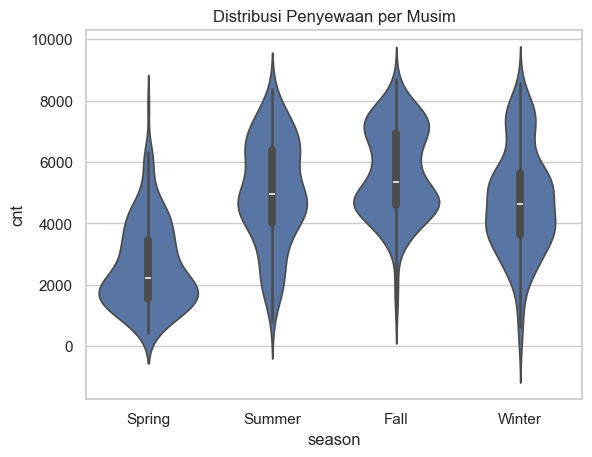

In [106]:
# Violin plot season
sns.violinplot(x="season", y="cnt", data=df)
plt.title("Distribusi Penyewaan per Musim")
plt.show()

**Insight:** Distribusi penyewaan sepeda pada setiap musim menunjukkan pola yang berbeda. Musim Fall dan Summer memiliki distribusi yang lebih lebar dengan kepadatan tinggi pada nilai cnt yang besar, menandakan banyak hari dengan penyewaan tinggi. Sebaliknya, Spring cenderung memiliki distribusi pada nilai yang lebih rendah. Winter berada di tengah, namun masih menunjukkan variasi yang cukup besar. Hal ini mengindikasikan bahwa musim berpengaruh signifikan terhadap intensitas penggunaan sepeda.

In [107]:
# Chi-Square Test antara workingday dan season
from scipy.stats import chi2_contingency

ct = pd.crosstab(df["workingday"], df["season"])
chi2, p, dof, expected = chi2_contingency(ct)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 0.6428486407877679
p-value: 0.8865568364019545


**Insight:** Hasil uji Chi-Square menunjukkan p-value yang sangat tinggi (> 0.05), sehingga tidak terdapat hubungan yang signifikan antara variabel workingday dan season. Artinya, distribusi hari kerja dan hari libur tidak dipengaruhi oleh musim tertentu, dan kedua variabel tersebut dapat dianggap independen.

# Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh suhu (temp) dan kelembaban (hum) terhadap jumlah penyewaan sepeda selama periode 2011–2012?

Untuk menjawab pertanyaan ini, dilakukan analisis hubungan antara suhu (temp), kelembaban (hum), dan jumlah penyewaan sepeda (cnt) menggunakan scatter plot dan regresi linear.


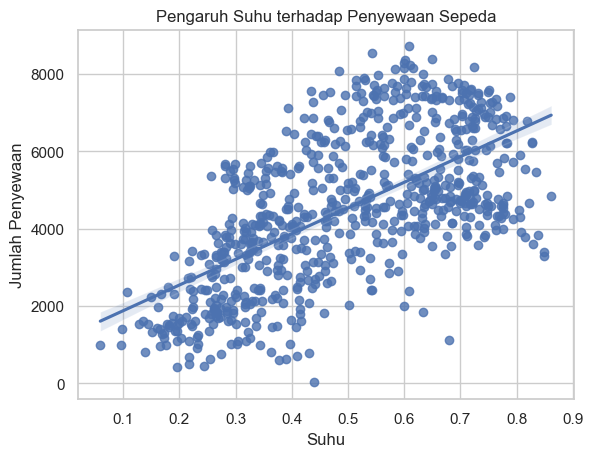

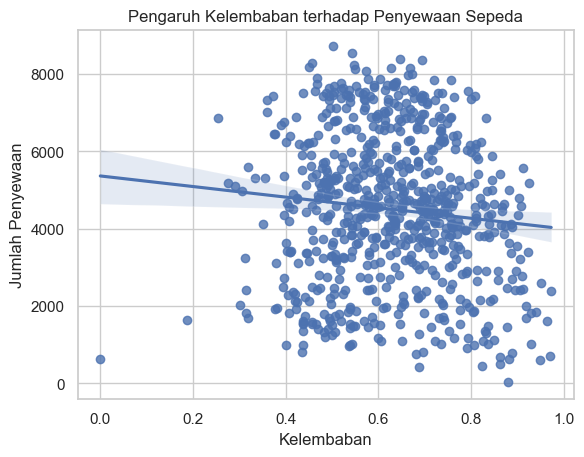

In [109]:
# Hubungan suhu terhadap penyewaan
sns.regplot(x="temp", y="cnt", data=df)
plt.title("Pengaruh Suhu terhadap Penyewaan Sepeda")
plt.xlabel("Suhu")
plt.ylabel("Jumlah Penyewaan")
plt.show()

# Hubungan kelembaban terhadap penyewaan
sns.regplot(x="hum", y="cnt", data=df)
plt.title("Pengaruh Kelembaban terhadap Penyewaan Sepeda")
plt.xlabel("Kelembaban")
plt.ylabel("Jumlah Penyewaan")
plt.show()

**Insight:** Hasil visualisasi menunjukkan bahwa suhu (temp) memiliki hubungan positif yang cukup kuat dengan jumlah penyewaan sepeda (cnt), di mana semakin tinggi suhu, jumlah penyewaan cenderung meningkat. Sebaliknya, kelembaban (hum) menunjukkan hubungan negatif, meskipun tidak terlalu kuat, di mana peningkatan kelembaban cenderung diikuti penurunan jumlah penyewaan. Hal ini mengindikasikan bahwa kondisi cuaca yang hangat dan tidak terlalu lembab merupakan kondisi yang paling ideal untuk aktivitas bersepeda.

### Pertanyaan 2: Bagaimana tren jumlah penyewaan sepeda (cnt) dari waktu ke waktu selama periode 2011–2012, dan kapan terjadi puncak serta penurunannya?

Untuk menjawab pertanyaan ini, dilakukan analisis tren jumlah penyewaan sepeda (cnt) berdasarkan waktu menggunakan line plot.

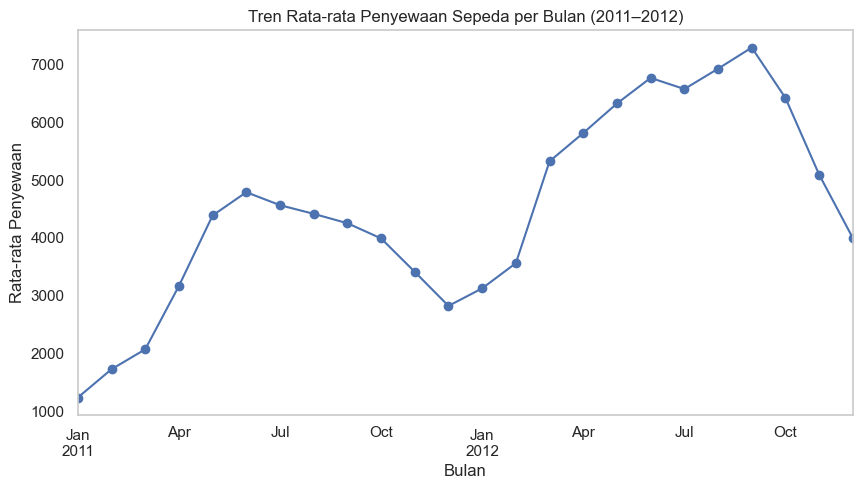

In [112]:
# Agregasi bulanan (rata-rata)
monthly_trend = df.resample('ME', on='dteday')['cnt'].mean()

# Plot tren bulanan
plt.figure(figsize=(10,5))
monthly_trend.plot(marker='o')

plt.title("Tren Rata-rata Penyewaan Sepeda per Bulan (2011–2012)")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata Penyewaan")
plt.grid()

plt.show()

**Insight:** Insight: Berdasarkan agregasi bulanan, terlihat bahwa tren penyewaan sepeda menunjukkan pola musiman yang konsisten pada periode 2011–2012. Jumlah penyewaan cenderung meningkat dari awal tahun dan mencapai puncaknya pada pertengahan tahun, terutama sekitar bulan Juni hingga September, sebelum kembali menurun menjelang akhir tahun. Pola ini terjadi pada kedua tahun, namun dengan tingkat penyewaan yang lebih tinggi pada tahun 2012 dibandingkan 2011, yang mengindikasikan adanya peningkatan penggunaan layanan dari waktu ke waktu. Penurunan yang terjadi di awal dan akhir tahun kemungkinan dipengaruhi oleh kondisi cuaca yang kurang mendukung, sehingga memperkuat indikasi bahwa faktor musiman memiliki peran penting dalam menentukan jumlah penyewaan sepeda.

### Pertanyaan 3: Apakah terdapat perbedaan jumlah penyewaan sepeda (cnt) antara hari kerja dan hari libur serta antar musim selama periode 2011–2012?

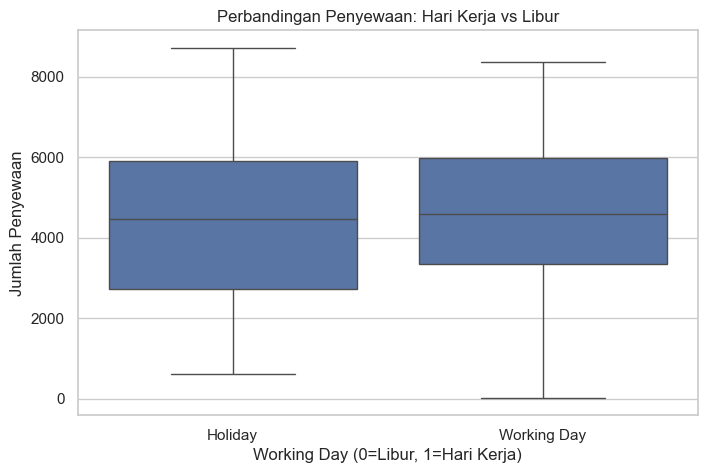

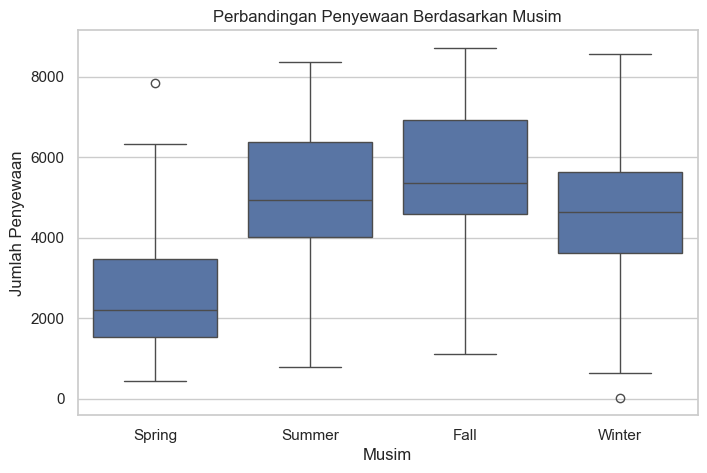

In [117]:
# Working Day
plt.figure(figsize=(8,5))
sns.boxplot(x="workingday", y="cnt", data=df)

plt.title("Perbandingan Penyewaan: Hari Kerja vs Libur")
plt.xlabel("Working Day (0=Libur, 1=Hari Kerja)")
plt.ylabel("Jumlah Penyewaan")

plt.show()

# Season
plt.figure(figsize=(8,5))
sns.boxplot(x="season", y="cnt", data=df)

plt.title("Perbandingan Penyewaan Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Jumlah Penyewaan")

plt.show()

**Insight:** Insight: Perbandingan menunjukkan bahwa jumlah penyewaan sepeda antara hari kerja dan hari libur relatif tidak berbeda jauh, meskipun hari kerja memiliki median sedikit lebih tinggi, sehingga penggunaan sepeda tidak hanya didominasi oleh aktivitas kerja tetapi juga cukup tinggi saat libur. Sebaliknya, faktor musim memberikan pengaruh yang lebih jelas, di mana musim Fall dan Summer memiliki jumlah penyewaan yang lebih tinggi dibandingkan Spring dan Winter, dengan Spring sebagai yang terendah, sehingga dapat disimpulkan bahwa variasi musim lebih berpengaruh terhadap jumlah penyewaan sepeda dibandingkan perbedaan hari kerja dan hari libur.

# Analisis Lanjutan (Opsional)

#### Distribusi Kategori Permintaan Sepeda (Binning)

In [118]:
# Membuat kategori berdasarkan jumlah penyewaan
bins = [0, 3000, 6000, df['cnt'].max()]
labels = ['Low', 'Medium', 'High']

df['demand_category'] = pd.cut(df['cnt'], bins=bins, labels=labels)

# Melihat distribusi kategori
df['demand_category'].value_counts()

demand_category
Medium    379
High      180
Low       172
Name: count, dtype: int64

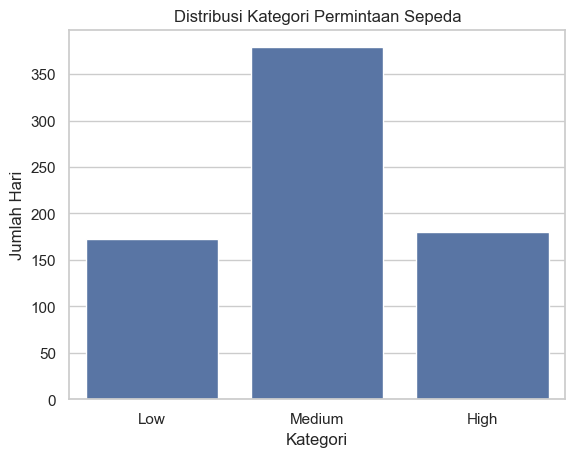

In [119]:
sns.countplot(x='demand_category', data=df)
plt.title("Distribusi Kategori Permintaan Sepeda")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Hari")
plt.show()

**Insight:** Berdasarkan hasil binning jumlah penyewaan, terlihat bahwa kategori permintaan didominasi oleh kategori Medium, diikuti oleh High dan Low yang relatif lebih sedikit dan hampir seimbang. Hal ini menunjukkan bahwa sebagian besar hari memiliki tingkat penyewaan yang stabil pada level menengah, sementara hari dengan permintaan sangat tinggi maupun sangat rendah terjadi lebih jarang. Pola ini mengindikasikan bahwa permintaan sepeda cenderung konsisten, dengan fluktuasi ekstrem hanya terjadi pada kondisi tertentu seperti musim atau cuaca tertentu.

#### Distribusi Kategori Permintaan Berdasarkan Musim

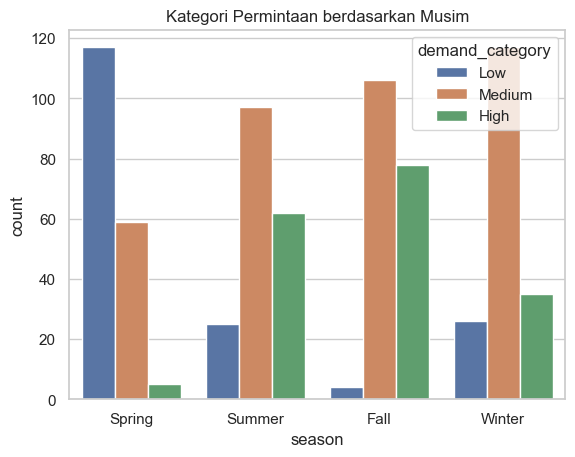

In [120]:
# Cek hubungan kategori dengan musim
sns.countplot(x='season', hue='demand_category', data=df)
plt.title("Kategori Permintaan berdasarkan Musim")
plt.show()

**Insight:** Distribusi kategori permintaan berdasarkan musim menunjukkan pola yang cukup jelas, di mana kategori Medium mendominasi di hampir semua musim, terutama pada Summer dan Fall. Pada musim Spring, kategori Low lebih dominan dibandingkan musim lainnya, menandakan permintaan cenderung masih rendah. Sementara itu, kategori High paling banyak muncul pada Summer dan Fall, yang menunjukkan bahwa periode tersebut merupakan puncak permintaan penyewaan sepeda. Pada Winter, permintaan mulai menurun kembali dengan berkurangnya kategori High. Secara keseluruhan, musim memiliki pengaruh terhadap tingkat permintaan, dengan tren meningkat dari Spring ke Summer/Fall, lalu menurun di Winter.

# Conclusion & Recommendation

### Conclusion

- **Conclusion pertanyaan 1:** Suhu (temp) memiliki hubungan positif yang cukup kuat terhadap jumlah penyewaan sepeda, di mana semakin tinggi suhu maka jumlah penyewaan cenderung meningkat. Sebaliknya, kelembaban (hum) menunjukkan hubungan negatif yang lebih lemah, sehingga kondisi cuaca yang hangat dan tidak terlalu lembab menjadi kondisi paling ideal untuk meningkatkan penyewaan.

- **Conclusion pertanyaan 2:** Tren penyewaan sepeda menunjukkan pola musiman yang konsisten, dengan peningkatan dari awal tahun dan mencapai puncak pada pertengahan tahun (sekitar Summer–Fall), lalu menurun kembali di akhir tahun. Selain itu, terdapat peningkatan jumlah penyewaan pada tahun 2012 dibandingkan 2011, yang mengindikasikan pertumbuhan penggunaan layanan dari waktu ke waktu.

- **Conclusion pertanyaan 3:** Perbedaan jumlah penyewaan antara hari kerja dan hari libur tidak terlalu signifikan, meskipun hari kerja sedikit lebih tinggi. Sebaliknya, faktor musim memiliki pengaruh yang lebih besar, di mana Summer dan Fall menunjukkan tingkat penyewaan tertinggi, sementara Spring dan Winter cenderung lebih rendah.

### Recommendation

- Meningkatkan ketersediaan sepeda dan operasional pada periode **musim ramai (Summer dan Fall)** untuk mengoptimalkan potensi permintaan.
- Menyediakan **promo atau strategi pemasaran khusus di musim sepi (Spring dan Winter)** untuk meningkatkan jumlah penyewaan.
- Mengoptimalkan layanan pada kondisi cuaca ideal (hangat dan tidak lembab), misalnya dengan **penyesuaian stok atau penempatan sepeda di lokasi strategis**.
- Mengembangkan strategi yang tidak hanya berfokus pada hari kerja, karena permintaan pada hari libur juga cukup tinggi dan stabil.
- Memanfaatkan tren peningkatan dari tahun ke tahun dengan **perencanaan ekspansi layanan atau penambahan armada sepeda**.